In [ ]:
%pip install torch torchvision 

In [1]:
import torch

In [7]:
# Tensoren ... n-dimensionale Arrays 
a = torch.tensor([[1.,2],[3,4]])
b = torch.tensor([[5.,6],[7,8]])

print(a+b)
print(a * b)
print(a @ b ) # Matrizenmultiplikation, torch.matmul(a,b)
print(a.shape, a.dtype)

tensor([[ 6.,  8.],
        [10., 12.]])
tensor([[ 5., 12.],
        [21., 32.]])
tensor([[19., 22.],
        [43., 50.]])
torch.Size([2, 2]) torch.float32


In [8]:
# Gradient 
# Autograd 
x = torch.tensor(2.0, requires_grad=True) # Gradient mitführen 
y = 3*x**2 - 4*x # Handrechnung: f'(x) = 6*x - 4 -> f'(2) = 8 
y.backward() # Rückwärtslauf
print(x.grad) 

tensor(8.)


In [ ]:
import torch.nn as nn # Neural Networks 

NN = nn.Linear(10, 1) # w*x + b, in Tensorflow heißt Dense, 10 Eingänge, 1 Ausgang

loss = nn.MSELoss() # loss, cost, criterion, crit 
optimizer = torch.optim.SGD(NN.parameters(), lr=1e-2) # Stochastic Gradient Descent, lr = learning rate
# Optimierung nach Gewichte & Bias 

input_data = torch.randn(10) # 10 Zufallszahlen als Eingabe 
y = torch.tensor([1.0]) # Zielgröße 

output = NN(input_data) # Vorhersage 

# Wie schlecht ist meine Vorhersage? 
loss_output = loss(output, y) # Wie weit bin ich von der Zielgröße entfernt?
print("Verlust vor dem Update:", loss_output)

# Berechne Gradienten 
loss_output.backward()
# Update Gewicht+Bias 
optimizer.step() # Optimierungsschritt = Update 
output_new = NN(input_data) # mit neuen Parametern 
loss_new = loss(output_new,y) # Man hofft, dass dieser Wert kleiner ist, als vorher 
print("Verlust nach dem Update:", loss_new)

Verlust vor dem Update: tensor(1.0279, grad_fn=<MseLossBackward0>)
Verlust nach dem Update: tensor(0.6736, grad_fn=<MseLossBackward0>)


# Hallo Welt der tiefen neuronalen Netze

In [106]:
from torchvision import datasets, transforms 

transform = transforms.Compose([
    transforms.ToTensor(), # Konvertiert Bilder zu Tensoren
    transforms.Normalize((0.5,), (0.5, ))
 ] # Normalierung der Daten  
)

train_data = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform) # Trainingsdaten
test_data = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform) # Testdaten 

train_loader = torch.utils.data.DataLoader(train_data, batch_size= 64, shuffle=True) # shuffle = Randomisieren, 
test_loader = torch.utils.data.DataLoader(test_data, batch_size = 64, shuffle=False) 



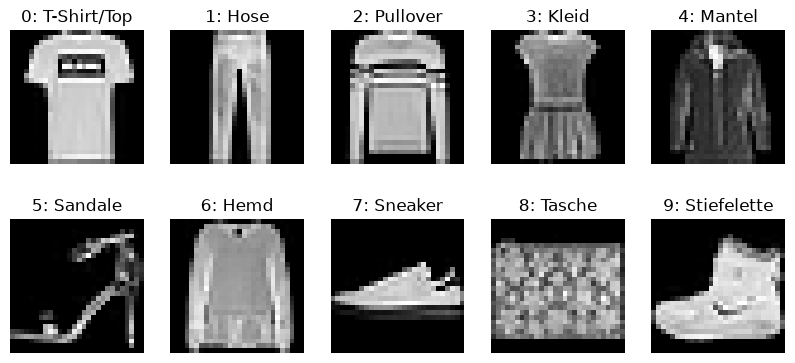

In [110]:
import matplotlib.pyplot as plt
klassen = ["T-Shirt/Top", "Hose", "Pullover", "Kleid", "Mantel","Sandale", "Hemd", "Sneaker", "Tasche", "Stiefelette"]
fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
for nummer, ax in enumerate(axes.flat):
    index = int((train_data.targets == nummer).nonzero()[0])
    ax.imshow(train_data[index][0][0], cmap="gray")
    ax.set_title(f"{nummer}: {klassen[nummer]}")
    ax.axis("off")
plt.show()

In [145]:
# Neuronales Netz mit zwei Linearschichten 

class NN(nn.Module): # 
    def __init__(self):
        super().__init__() # aus nn.Module erben 
        self.flatten = nn.Flatten() # 1x28x28 Pixel -> Vektor der Länge 784  
        self.layer1 = nn.Linear(28*28, 128) # 128 Neuronen (immer Zweierpotenzen)
        self.output = nn.Linear(128, 10) # 128 -> 10 Klassen 

    def forward(self,x): # wie werden die Daten vorwärts propagiert? 
        x = self.flatten(x)
        x = self.layer1(x) # x = Wx + b 
        x = torch.relu(x) # ReLU(x) 
        return self.output(x) # ohne Aktivierung, weil Multiklassen-Problem und wir nn.CrossEntropy verwenden

class NN(nn.Module): # 
    def __init__(self):
        super().__init__() # 
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self,x):
        return self.model(x)

In [146]:
model = NN()

# ein Batch durch das untrainierte Netz 
bilder, labels = next(iter(train_loader))
with torch.no_grad():                        # nur ansehen, keine Gradienten nötig
    outputs = model(bilder)

print("vorhergesagt:", outputs.argmax(dim=1)[:8].tolist())
print("wahr:        ", labels[:8].tolist())

vorhergesagt: [8, 1, 8, 8, 1, 8, 9, 4]
wahr:         [1, 6, 5, 4, 6, 3, 0, 9]


In [147]:
def train_model(model, optimizer, n_epochs=10):
    loss_fn = nn.CrossEntropyLoss() # weil mehrere Klassen 
    verluste = [] 
    for epoch in range(n_epochs): # Training Loop... 1 Epoche = 1 Mal hat ML Algorithmus den Datensatz vollständig gesehen 
        model.train() # Trainingsmodus 
        running_loss = 0.0 # laufende Kosten 
        for images, labels in train_loader: # batchweise die Daten rausholen 
            optimizer.zero_grad()           # alte Gradienten löschen 
            outputs = model(images) # Vorwärtslauf
            loss = loss_fn(outputs, labels) # Verlust, wie schlecht ist mein Modell? 
            loss.backward() # Rückwärtslauf = Gradienten berechnen 
            optimizer.step() # Anpassung der Gewichte 
            running_loss += loss.item()
        verluste.append(running_loss / len(train_loader)) # Durchschnitt bilden 
        print(f"Epoche {epoch+1}/{n_epochs}, Verlust: {verluste[-1]:.4f}")

    return verluste

model = NN()
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)
verluste = train_model(model, optimizer, n_epochs=20)

Epoche 1/20, Verlust: 0.4900
Epoche 2/20, Verlust: 0.3662
Epoche 3/20, Verlust: 0.3277
Epoche 4/20, Verlust: 0.3026
Epoche 5/20, Verlust: 0.2830
Epoche 6/20, Verlust: 0.2662
Epoche 7/20, Verlust: 0.2518
Epoche 8/20, Verlust: 0.2379
Epoche 9/20, Verlust: 0.2287
Epoche 10/20, Verlust: 0.2202
Epoche 11/20, Verlust: 0.2077
Epoche 12/20, Verlust: 0.1963
Epoche 13/20, Verlust: 0.1879
Epoche 14/20, Verlust: 0.1796
Epoche 15/20, Verlust: 0.1736
Epoche 16/20, Verlust: 0.1677
Epoche 17/20, Verlust: 0.1579
Epoche 18/20, Verlust: 0.1551
Epoche 19/20, Verlust: 0.1447
Epoche 20/20, Verlust: 0.1375


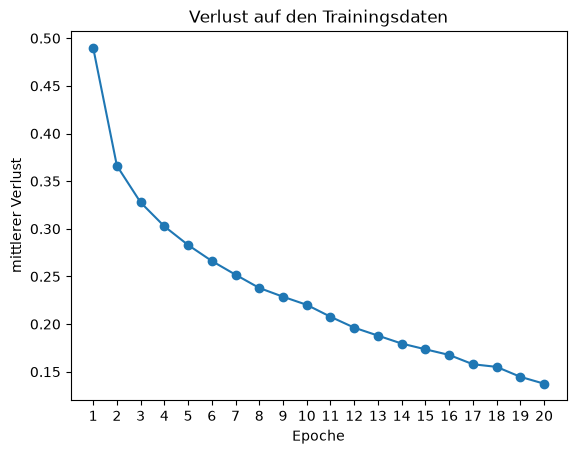

In [148]:
fig, ax = plt.subplots()
ax.plot(range(1, len(verluste) + 1), verluste, marker="o")
ax.set_xticks(range(1, len(verluste) + 1))
ax.set_xlabel("Epoche")
ax.set_ylabel("mittlerer Verlust")
ax.set_title("Verlust auf den Trainingsdaten")
plt.show()

In [149]:
bilder, labels = next(iter(train_loader))
with torch.no_grad():                        # nur ansehen, keine Gradienten nötig
    outputs = model(bilder)

print("vorhergesagt:", outputs.argmax(dim=1)[:8].tolist())
print("wahr:        ", labels[:8].tolist())

vorhergesagt: [1, 0, 3, 7, 6, 3, 0, 6]
wahr:         [1, 0, 3, 7, 6, 3, 0, 6]


In [150]:
def predict(model, loader):
    # Liefert zwei Tensoren: vorhersage und wahre Klassen für alle Bilder aus Testdatensatz 
    model.eval()
    images_pred, images_true = [], []
    with torch.no_grad(): # keine Gradienten nötig
        for images, labels in loader:
            outputs = model(images)
            images_pred.append(outputs.argmax(dim=1)) # Klassen berechnen 
            images_true.append(labels)

    return torch.cat(images_pred), torch.cat(images_true)

pred, true = predict(model, test_loader)
correct = (pred == true).sum().item()
correct / len(true) # Genauigkeit 


0.8863

In [151]:
# Confusion-Matrix 
import pandas as pd
wahr_name = pd.Series(true.numpy(), name="wahr").map(lambda i: klassen[i])
pred_name = pd.Series(pred.numpy(), name="vorhergesagt").map(lambda i: klassen[i])
tabelle = pd.crosstab(wahr_name, pred_name).reindex(index=klassen, columns=klassen, fill_value=0)
tabelle

vorhergesagt,T-Shirt/Top,Hose,Pullover,Kleid,Mantel,Sandale,Hemd,Sneaker,Tasche,Stiefelette
wahr,,,,,,,,,,
T-Shirt/Top,884,4,13,18,3,2,71,0,5,0
Hose,5,978,0,10,4,0,2,0,1,0
Pullover,23,1,832,6,51,1,83,0,3,0
Kleid,40,15,12,867,44,0,18,0,4,0
Mantel,1,1,111,22,782,0,83,0,0,0
Sandale,0,0,0,0,0,969,0,21,0,10
Hemd,170,1,76,20,42,0,689,0,2,0
Sneaker,0,0,0,0,0,24,0,938,0,38
Tasche,6,0,5,4,6,3,6,4,966,0


In [197]:
# Einzelwerte pro Klasse aus der Confusion-Matrix ablegen
# Zeile = wahre Klasse, Spalte = vorhergesagte Klasse
import numpy as np
M = tabelle.to_numpy()

TP = np.diag(M)                  # Diagonale: richtig erkannt
FP = M.sum(axis=0) - TP          # Spaltensumme minus Diagonale: als diese Klasse vorhergesagt, war aber eine andere
FN = M.sum(axis=1) - TP          # Zeilensumme minus Diagonale: war diese Klasse, wurde aber als andere erkannt
TN = M.sum() - TP - FP - FN      # der Rest

kennzahlen = pd.DataFrame({"TP": TP, "FP": FP, "FN": FN, "TN": TN}, index=klassen)
kennzahlen["Precision"] = kennzahlen.TP / (kennzahlen.TP + kennzahlen.FP)   # von den als X vorhergesagten: wie viele waren X?
kennzahlen["Recall"]    = kennzahlen.TP / (kennzahlen.TP + kennzahlen.FN)   # von den echten X: wie viele wurden erkannt?
kennzahlen.round(3)

,TP,FP,FN,TN,Precision,Recall
T-Shirt/Top,845,165,155,8835,0.837,0.845
Hose,979,17,21,8983,0.983,0.979
Pullover,747,133,253,8867,0.849,0.747
Kleid,852,62,148,8938,0.932,0.852
Mantel,858,230,142,8770,0.789,0.858
Sandale,974,46,26,8954,0.955,0.974
Hemd,756,332,244,8668,0.695,0.756
Sneaker,955,51,45,8949,0.949,0.955
Tasche,977,41,23,8959,0.960,0.977
Stiefelette,953,27,47,8973,0.972,0.953


In [ ]:
# Beispiel: Einzelwerte für eine Klasse nachschlagen
kennzahlen.loc["Hemd", ["FP", "FN"]]

# Hyperparameter-Suche mit Optuna

Bisher haben wir Lernrate, Schichtbreite und Optimierer von Hand gewählt. Optuna probiert das systematisch aus:
wir schreiben eine Funktion `objective(trial)`, die einen Parametersatz vorschlägt, kurz trainiert und eine Kennzahl zurückgibt.
Optuna lernt aus den bisherigen Versuchen, wo sich die Suche lohnt (Bayes-Optimierung, kein Grid Search).

In [ ]:
%pip install optuna

In [ ]:
import optuna
from torch.utils.data import Subset, DataLoader

# Für die Suche reicht ein Ausschnitt der Daten, sonst dauert jeder Versuch zu lange
# 20.000 Bilder zum Trainieren, 5.000 zum Bewerten (aus den Trainingsdaten, Testdaten bleiben unberührt!)
generator = torch.Generator().manual_seed(0)
perm = torch.randperm(len(train_data), generator=generator)
search_train = Subset(train_data, perm[:20_000].tolist())
search_valid = Subset(train_data, perm[20_000:25_000].tolist())

search_train_loader = DataLoader(search_train, batch_size=64, shuffle=True)
search_valid_loader = DataLoader(search_valid, batch_size=256, shuffle=False)

In [ ]:
def build_model(n_layers, hidden_size, dropout):
    # Netz mit variabler Tiefe und Breite, damit Optuna die Architektur mitwählen kann
    layers = [nn.Flatten()]
    in_features = 28 * 28
    for _ in range(n_layers):
        layers += [nn.Linear(in_features, hidden_size), nn.ReLU(), nn.Dropout(dropout)]
        in_features = hidden_size
    layers.append(nn.Linear(in_features, 10))
    return nn.Sequential(*layers)


def accuracy(model, loader):
    pred, true = predict(model, loader)   # Funktion von oben wiederverwenden
    return (pred == true).float().mean().item()


def objective(trial):
    # 1. Optuna schlägt Werte vor: Suchraum definieren
    n_layers = trial.suggest_int("n_layers", 1, 3)
    hidden_size = trial.suggest_categorical("hidden_size", [64, 128, 256, 512])
    dropout = trial.suggest_float("dropout", 0.0, 0.5)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)   # log: 1e-4 und 1e-3 gleich wahrscheinlich
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "SGD"])

    # 2. Modell und Optimierer aus den Vorschlägen bauen
    model = build_model(n_layers, hidden_size, dropout)
    optimizer = getattr(torch.optim, optimizer_name)(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    # 3. Kurz trainieren, nach jeder Epoche bewerten
    for epoch in range(3):
        model.train()
        for images, labels in search_train_loader:
            optimizer.zero_grad()
            loss_fn(model(images), labels).backward()
            optimizer.step()

        acc = accuracy(model, search_valid_loader)

        # 4. Zwischenstand melden, aussichtslose Versuche früh abbrechen (Pruning)
        trial.report(acc, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return acc   # Optuna maximiert diesen Wert

In [ ]:
optuna.logging.set_verbosity(optuna.logging.WARNING)   # weniger Ausgabe pro Versuch

study = optuna.create_study(
    direction="maximize",                                   # Genauigkeit soll hoch
    sampler=optuna.samplers.TPESampler(seed=42),            # Bayes-artiger Sampler, reproduzierbar
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5), # ab Versuch 6: schlechter als Median -> abbrechen
)
study.optimize(objective, n_trials=20, show_progress_bar=True)

print("Beste Genauigkeit:", round(study.best_value, 4))
print("Beste Parameter:  ", study.best_params)

In [ ]:
# Alle Versuche als Tabelle: state zeigt, welche Versuche abgebrochen wurden (PRUNED)
study.trials_dataframe(attrs=("number", "value", "state", "params")).sort_values("value", ascending=False).head(10)

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=optuna.exceptions.ExperimentalWarning)  # Plotfunktionen sind offiziell noch experimentell

# Welche Parameter haben den größten Einfluss?
optuna.visualization.matplotlib.plot_param_importances(study)
plt.show()

# Verlauf der Suche: wird die beste Genauigkeit mit der Zeit besser?
optuna.visualization.matplotlib.plot_optimization_history(study)
plt.show()

In [ ]:
# Mit den besten Parametern nochmal auf allen Trainingsdaten trainieren und auf den Testdaten bewerten
best = study.best_params
model_best = build_model(best["n_layers"], best["hidden_size"], best["dropout"])
optimizer = getattr(torch.optim, best["optimizer"])(model_best.parameters(), lr=best["lr"])
verluste_best = train_model(model_best, optimizer, n_epochs=10)

print("Genauigkeit auf Testdaten (Handwahl):", round(accuracy(model, test_loader), 4))
print("Genauigkeit auf Testdaten (Optuna):  ", round(accuracy(model_best, test_loader), 4))

In [ ]:
# Modell

model.state_dict()

In [ ]:
%pip install onnx onnxscript

In [164]:
import torch.onnx 
example = train_data[index][0].unsqueeze(0)   
onnx = torch.onnx.export(model, example, dynamo=True)

[torch.onnx] Obtain model graph for `NN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `NN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅


In [165]:
onnx.optimize()
onnx.save("fashionmnist.onnx")
